# Numerical Integration of the Damped Harmonic Oscillator

Roman le Bon

---

## 1 Introduction
### 1.1 Project Aim

Many physical systems can be described by differential equations governing how quantities evolve in time. One important example is the damped spring–mass system, which appears across physics and engineering - from mechanical oscillators and shock absorbers to electrical RLC circuits and molecular vibrations.

In a realistic oscillator, energy is gradually dissipated through damping forces such as friction or resistance. When an external force $F(t)$ is also applied, the equation of motion becomes

$$
m\ddot{x}(t) + b\dot{x}(t) + kx(t) = F(t),
$$

where $x(t)$ is the displacement from equilibrium, $m$ is the mass, $k$ is the spring constant, and $b$ is the damping coefficient.

This can be rewritten as two coupled first-order ODEs,

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = \frac{F(t) - kx - bv}{m},
$$

which is the form used by all numerical integration methods in this project.

Analytical solutions exist only for special cases, notably $F(t) = 0$. Thus, numerical methods are essential for exploring the full range of physical behaviour. The behaviour of the unforced system depends critically on the **critical damping coefficient** $b_{cr} = 2\sqrt{km}$:

| Regime | Condition | Behaviour |
|---|---|---|
| Underdamped | $b < b_{cr}$ | Oscillatory decay |
| Critically damped | $b = b_{cr}$ | Fastest non-oscillatory return to equilibrium |
| Overdamped | $b > b_{cr}$ | Slow exponential decay, no oscillation |


In this project, four numerical integration methods are implemented and compared against the analytical solution, before being used to explore the physical behaviour of the system under varying damping conditions and external forcing.

### 1.2 Simulation Setup

Before implementing the numerical algorithms, we define the physical parameters of the system, the timestep used in the numerical integration, and the initial conditions for the oscillator.

We begin by first initialising our Python interpreter:

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import cmath

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
plt.style.use('default')

The system parameters assigned for this project are

$$
\begin{aligned}
&k = 2.17 \; \text{kg/$\text{s}^2$}, \\
&m = 4.68 \; \text{kg},
\end{aligned}
$$

and are implemented, along with the initial conditions, below.

In [95]:
# Fixed system parameters 
m = 4.68    # Mass (kg)
k = 2.17    # Spring constant (N/m)

# Initial conditions
x_0 =  0.0  # Initial displacement (m)
v_0 = -1.0  # Initial velocity (m/s)

# Simulation parameters
T = 200
h = 0.01
nsteps = int(T/h)

# Damping coefficient - varied later when exploring damping regimes
b = 0.1     # kg/s

A timestep of $h=0.01$ is chosen as a compromise between computational efficiency and numerical accuracy. The influence of timestep size on numerical error will be investigated later.

The oscillator starts at equilibrium, with an initial velocity of $v_0 = -1$ m/s.

An initial damping coefficient of $b = 0.1$ kg/s is chosen, giving an underdamped system ($b \ll b_{cr}$). This produces clear oscillatory decay, making it the most suitable regime for comparing the accuracy of the four numerical methods. The effect of varying $b$ is investigated later.

## 2 Numerical Methods

Four numerical integration methods are implemented to solve the equation of motion. Each method is coded as a function accepting the same interface, allowing direct comparison. An external force $F(t)$ can optionally be passed to each method; if none is provided, the unforced case $F(t) = 0$ is assumed.

The acceleration at each timestep is given by

$$a_i = \frac{F(t_i) - kx_i - bv_i}{m},$$

and is computed by a shared helper function used by all four methods.

In [96]:
def acceleration(x, v, t, b, F=None):
    """
    Compute the acceleration of the oscillator at a given state.

    Parameters
    ----------
    x : float  - position (m)
    v : float  - velocity (m/s)
    t : float  - time (s)
    b : float  - damping coefficient (kg/s)
    F : callable or None - external force F(t); defaults to zero if None
    """
    F_t = F(t) if F is not None else 0.0
    return (F_t - k*x - b*v) / m

### 2.1 Euler's Method

The simplest first-order method. Position and velocity are updated using the state at the current timestep only:

$$
x_{i+1} = x_i + hv_i,
$$

$$
v_{i+1} = v_i + ha_i,
$$

where $a_i = -\frac{k}{m}x_i - \frac{b}{m}v_i$, with step number $i$, and time step $h$.

From the Taylor expansion $x(t+h) = x(t) + hx'(t) + \frac{1}{2}h^2x''(\zeta)$, the local truncation error is $O(h^2)$, giving a **global error of $O(h)$** - the error accumulated over the full simulation decreases linearly as $h$ is reduced. This makes it the least accurate of the four methods implemented here.

A further limitation is that Euler's method is not energy-conserving - for an undamped oscillator the total energy grows at each step, causing the amplitude to increase unphysically over long integration times.

On the other hand, Euler's method is straightforward to implement and understand, making it a useful baseline against which more sophisticated methods can be compared.

In [97]:
def Euler(x_0, v_0, nsteps, h, b, F=None):
    """
    Solve the damped harmonic oscillator using Euler's method.

    Parameters
    ----------
    x_0, v_0 : float - initial position (m) and velocity (m/s)
    nsteps   : int   - number of timesteps
    h        : float - timestep size (s)
    b        : float - damping coefficient (kg/s)
    F        : callable or None - external force F(t); defaults to zero
    """

    # Arrays for position and velocity at each timestep
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)

    # Apply initial conditions
    x[0], v[0] = x_0, v_0

    for i in range(nsteps - 1):
        
        # Current time
        t_i = i * h

        # Compute acceleration from current state
        a = acceleration(x[i], v[i], t_i, b, F)

        # Update position and velocity using current velocity and acceleration
        x[i+1] = x[i] + h * v[i]
        v[i+1] = v[i] + h * a

    # Build time array corresponding to each step
    t = np.arange(0, nsteps * h, h)
    return t, x, v

The numerical solution is plotted below.

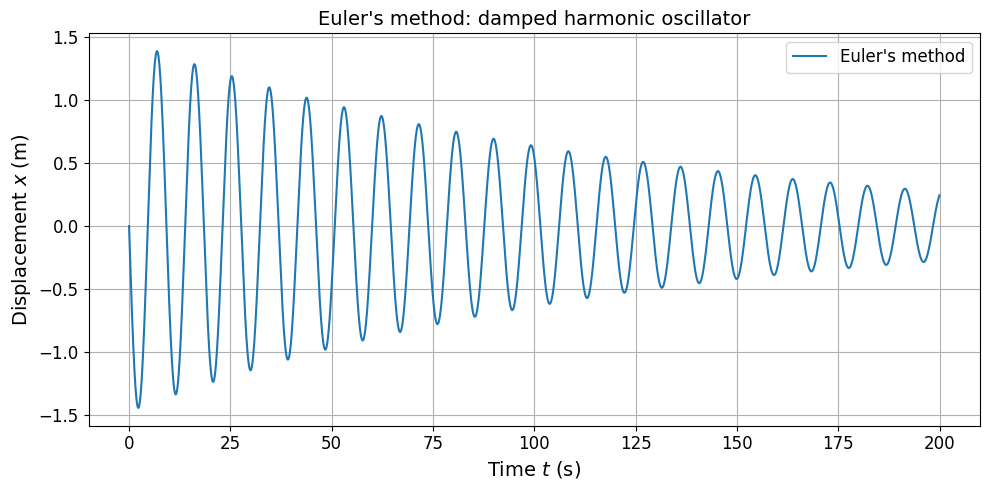

In [98]:
# Run Euler's method with default parameters
t_eu, x_eu, v_eu = Euler(x_0, v_0, nsteps, h, b)

plt.figure(figsize=(10, 5))
plt.plot(t_eu, x_eu, label="Euler's method")
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Euler's method: damped harmonic oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The solution shows oscillatory decay consistent with the applied damping. The amplitude does not grow visibly at this timestep size - the artificial energy gain predicted by theory is outweighed by the physical damping for these parameters. This energy gain can be demonstrated clearly in the undamped case ($b=0$), where it can be shown analytically that

$$
E_{i+1} = E_i\left(1 + \frac{k}{m}h^2\right),
$$

meaning energy grows without bound regardless of timestep size. The deviation from the true solution will become clearer when compared against the analytical solution.

### 2.2 Improved Euler's Method

An improvement on the standard Euler method can be obtained by including one extra term in the Taylor expansion for position:

$$
x_{i+1} = x_i + hv_i + \frac{h^2}{2}a_i,
$$

$$
v_{i+1} = v_i + ha_i,
$$

where $a_i = -\frac{k}{m}x_i - \frac{b}{m}v_i$, with step number $i$ and time step $h$.

This reduces the local truncation error on position to $O(h^3)$. However, the velocity update remains first-order with local truncation error $O(h^2)$. Since the acceleration depends on velocity through $a_i = (F_i - kx_i - bv_i)/m$, the first-order velocity error feeds back into the position calculation at subsequent steps, limiting the effective global error to $O(h)$ in practice. This is later confirmed by the quantitative comparison in Section 4. Despite this, the method achieves a noticeably smaller error prefactor than standard Euler.

Like standard Euler, this method is straightforward to implement - the only additional complexity is the extra $\frac{h^2}{2}a_i$ term in the position update. Despite this simplicity, the improvement in accuracy over long integration times is substantial.

In [99]:
def ImprovedEuler(x_0, v_0, nsteps, h, b, F=None):
    """
    Solve the damped harmonic oscillator using the Improved Euler's method.

    Parameters
    ----------
    x_0, v_0 : float - initial position (m) and velocity (m/s)
    nsteps   : int   - number of timesteps
    h        : float - timestep size (s)
    b        : float - damping coefficient (kg/s)
    F        : callable or None - external force F(t); defaults to zero
    """
    # Preallocate arrays for position and velocity at each timestep
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)

    # Apply initial conditions
    x[0], v[0] = x_0, v_0

    for i in range(nsteps - 1):

        # Current time
        t_i = i * h

        # Compute acceleration at current state
        a = acceleration(x[i], v[i], t_i, b, F)

        # Update position using extra Taylor term, velocity using current acceleration
        x[i+1] = x[i] + h * v[i] + 0.5 * h**2 * a
        v[i+1] = v[i] + h * a

    # Build time array corresponding to each step
    t = np.arange(0, nsteps * h, h)

    return t, x, v

The numerical solution is plotted below.

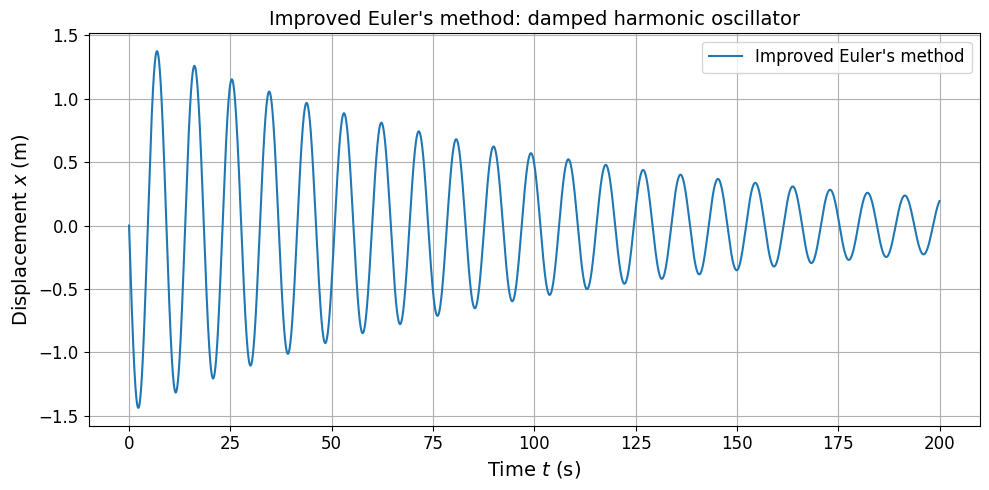

In [100]:
t_ie, x_ie, v_ie = ImprovedEuler(x_0, v_0, nsteps, h, b)

plt.figure(figsize=(10, 5))
plt.plot(t_ie, x_ie, label="Improved Euler's method")
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Improved Euler's method: damped harmonic oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The solution shows stable oscillatory decay. The higher-order position update eliminates the monotonic energy drift seen in standard Euler, although small errors may still accumulate over very long integration times. A quantitative comparison with the analytical solution follows in the next section.

### 2.3 Verlet's Method

Verlet's method uses a centred difference scheme, writing two Taylor expansions:

$$
x(t+h) = x(t) + hx'(t) + \frac{1}{2}h^2x''(t) + \frac{1}{6}h^3x'''(\zeta),
$$

$$
x(t-h) = x(t) - hx'(t) + \frac{1}{2}h^2x''(t) - \frac{1}{6}h^3x'''(\zeta).
$$

Adding these and rearranging gives the position update:

$$
x_{i+1} = 2x_i - x_{i-1} + h^2a_i,
$$

with the velocity estimated from the centred difference:

$$
v_i = \frac{x_{i+1} - x_{i-1}}{2h}.
$$

Since the velocity appears in the acceleration, these equations cannot be solved independently.

Substituting the centred difference expression for $v_i$ into the acceleration and rearranging gives a position update that depends only on previous positions:

$$
x_{i+1} = Ax_i + Bx_{i-1},
$$

where

$$
A = \dfrac{2(2m - kh^2)}{D}, \quad B = \dfrac{bh - 2m}{D}, \quad D = 2m + bh.
$$

The local truncation error is $O(h^4)$, giving a **global error of $O(h^2)$** - making it the most accurate of the four methods implemented here, as confirmed by the quantitative comparison in Section 4.

A key limitation is that Verlet's method is **not self-starting**. The $(i+1)\text{th}$ step requires both $x_i$ and $x_{i-1}$, so the first step must be computed separately using the Improved Euler method. Despite this additional complexity, Verlet's method is widely used in physics simulations due to its excellent long-time stability.

In [101]:
def Verlet(x_0, v_0, nsteps, h, b, F=None):
    """
    Solve the damped harmonic oscillator using Verlet's method.

    Parameters
    ----------
    x_0, v_0 : float - initial position (m) and velocity (m/s)
    nsteps   : int   - number of timesteps
    h        : float - timestep size (s)
    b        : float - damping coefficient (kg/s)
    F        : callable or None - external force F(t); defaults to zero
    """
    # Preallocate arrays for position and velocity at each timestep
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)

    # Apply initial conditions
    x[0], v[0] = x_0, v_0

    # Bootstrap first step using Improved Euler - Verlet is not self-starting
    a_0  = acceleration(x[0], v[0], 0.0, b, F)
    x[1] = x[0] + h * v[0] + 0.5 * h**2 * a_0
    v[1] = v[0] + h * a_0

    # Precompute Verlet coefficients from lecture notes derivation
    D = 2*m + b*h
    A = 2*(2*m - k*h**2) / D
    B = (b*h - 2*m) / D

    for i in range(1, nsteps - 1):

        # Update position using only previous positions - velocity not needed
        t_i = i * h
        F_i = F(t_i) if F is not None else 0.0
        x[i+1] = A * x[i] + B * x[i-1] + 2 * h**2 * F_i / D

        # Estimate velocity using centred difference once x[i+1] is known
        v[i] = (x[i+1] - x[i-1]) / (2 * h)

    # Build time array corresponding to each step
    t = np.arange(0, nsteps * h, h)

    return t, x, v

The numerical solution is plotted below.

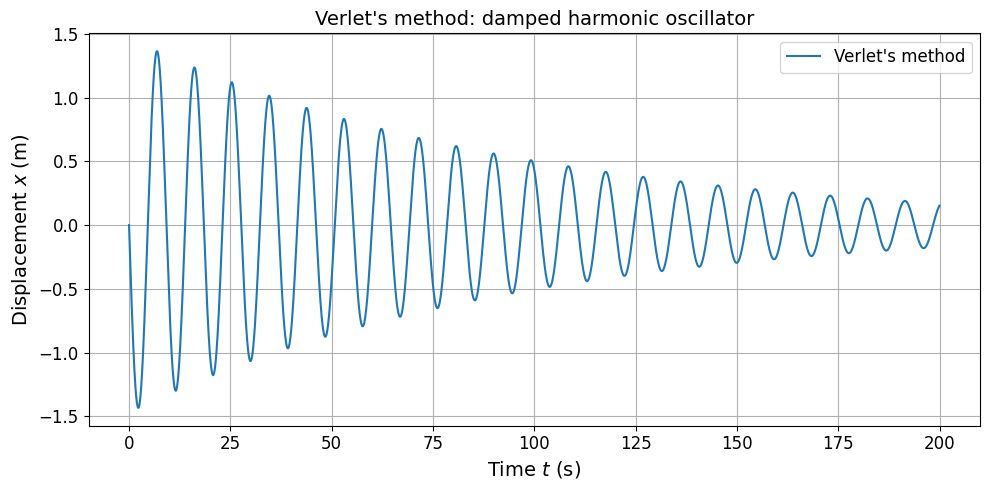

In [102]:
t_vl, x_vl, v_vl = Verlet(x_0, v_0, nsteps, h, b)

plt.figure(figsize=(10, 5))
plt.plot(t_vl, x_vl, label="Verlet's method")
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Verlet's method: damped harmonic oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The solution shows smooth, stable decay over the full 200 s integration window. The bootstrap step introduces no visible discontinuity, so the Improved Euler initialisation appears sufficient for the first step. Compared with standard Euler and Improved Euler, Verlet also avoids the clear long-term energy drift seen in those methods.

### 2.4 Euler-Cromer Method

The Euler-Cromer method makes a subtle but important modification to the standard 
Euler method - the velocity is updated first, and the updated velocity is then used 
to advance the position:

$$
v_{i+1} = v_i + ha_i,
$$

$$
x_{i+1} = x_i + hv_{i+1}.
$$

Note, the key difference from standard Euler: $x_{i+1}$ uses $v_{i+1}$ rather than 
$v_i$. This seemingly minor change has a profound effect on the energy behaviour of 
the method.

The local truncation error remains $O(h^2)$, giving the same **global error of $O(h)$** as standard Euler - so the two methods are of the same order of accuracy. However, Euler-Cromer is a **symplectic integrator**, so for oscillatory systems it tends to preserve the overall energy behaviour better, with the energy error oscillating rather than drifting steadily over time.

Unlike standard Euler, which predicts steadily increasing energy in the undamped case, Euler-Cromer produces energy that oscillates around the true value rather than drifting monotonically, making it far more suitable for long-time simulations of oscillatory systems.

Despite being only marginally more complex than standard Euler, Euler-Cromer combines ease of implementation with excellent long-time stability.

In [103]:
def EulerCromer(x_0, v_0, nsteps, h, b, F=None):
    """
    Solve the damped harmonic oscillator using the Euler-Cromer method.

    Parameters
    ----------
    x_0, v_0 : float - initial position (m) and velocity (m/s)
    nsteps   : int   - number of timesteps
    h        : float - timestep size (s)
    b        : float - damping coefficient (kg/s)
    F        : callable or None - external force F(t); defaults to zero
    """
    # Preallocate arrays for position and velocity at each timestep
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)

    # Apply initial conditions
    x[0], v[0] = x_0, v_0

    for i in range(nsteps - 1):

        # Current time
        t_i = i * h

        # Compute acceleration at current state
        a = acceleration(x[i], v[i], t_i, b, F)

        # Update velocity first
        v[i+1] = v[i] + h * a

        # Update position using the new velocity - key difference from Euler
        x[i+1] = x[i] + h * v[i+1]

    # Build time array corresponding to each step
    t = np.arange(0, nsteps * h, h)

    return t, x, v

The numerical solution is plotted below.

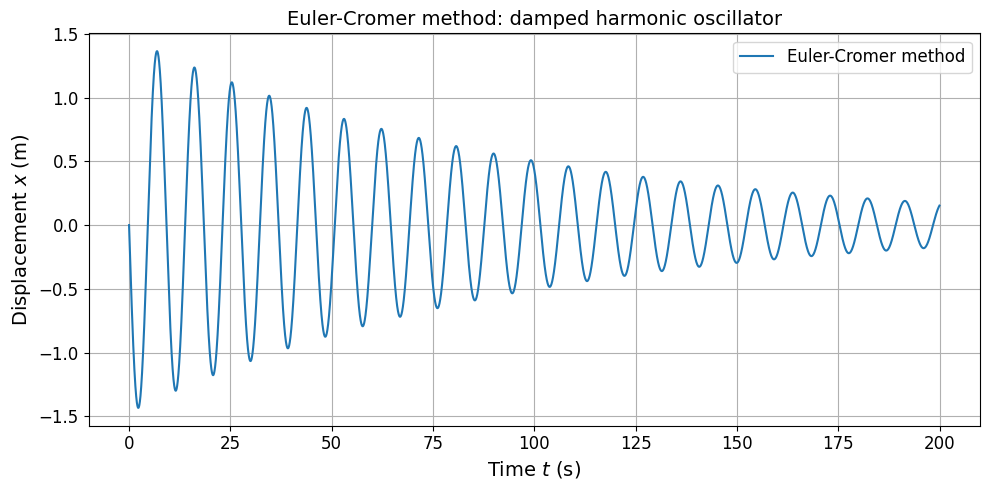

In [104]:
t_ec, x_ec, v_ec = EulerCromer(x_0, v_0, nsteps, h, b)

plt.figure(figsize=(10, 5))
plt.plot(t_ec, x_ec, label="Euler-Cromer method")
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Euler-Cromer method: damped harmonic oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The solution shows stable oscillatory decay over the full 200 s integration window. Because Euler–Cromer is symplectic, any energy error tends to oscillate around the true value rather than grow steadily over time - a stark contrast to standard Euler, where the undamped energy grows as $E_{i+1} = E_i\left(1 + \frac{k}{m}h^2\right)$. This property becomes most significant in the undamped case or over very long integration times, where non-symplectic methods diverge significantly from the true solution.

## 3 Analytical Solution

### 3.1 Derivation and Implementation

For the unforced case $F(t) = 0$, an exact analytical solution exists. As introduced in Section 1, the behaviour depends on $b$ relative to $b_{cr} = 2\sqrt{km}$. Here we derive the exact solution for each regime.

The equation of motion

$$
m\ddot{x} + b\dot{x} + kx = 0,
$$

has the general solution

$$
x(t) = e^{-\gamma t/2}\left(Ae^{i\omega t} + Be^{-i\omega t}\right),
$$

where $A$ and $B$ are constants determined by the initial conditions, and

$$\gamma = \frac{b}{m}, \qquad \omega_0 = \sqrt{\frac{k}{m}}, \qquad \omega^2 = \omega_0^2 - \frac{\gamma^2}{4}.$$

Here $\gamma$ is the damping ratio, $\omega_0$ is the natural frequency of the undamped system, and $\omega$ is the actual oscillation frequency modified by damping. Using the quality factor $Q = \omega_0/\gamma$, the three regimes are:

- If $Q > \frac{1}{2}$ ($b < b_{cr}$): The system is **underdamped**: $\omega^2 > 0$, giving oscillatory decay
- If $Q = \frac{1}{2}$ ($b = b_{cr}$): The system is **critically damped**: $\omega = 0$, fastest non-oscillatory return to equilibrium  
- If $Q < \frac{1}{2}$ ($b > b_{cr}$): The system is **overdamped**: $\omega^2 < 0$, slow exponential decay with no oscillation

For the **underdamped** case, $\omega$ is real and the solution is oscillatory. Applying the initial conditions $x(0) = x_0$ and $\dot{x}(0) = v_0$ gives the constants $A$ and $B$, which are computed in the implementation below.

For the **critically damped** case ($\omega = 0$), the general solution above is no longer valid and the solution takes the form:

$$
x(t) = (C_1 + C_2 t)e^{-\gamma t/2},
$$

where $C_1 = x_0$ and $C_2 = v_0 + \frac{\gamma}{2}x_0$.

For the **overdamped** case, $\omega^2 < 0$ so $\omega$ is purely imaginary. Writing $r_{1,2} = -\frac{\gamma}{2} \pm \sqrt{\frac{\gamma^2}{4} - \omega_0^2}$, the solution is a sum of two real decaying exponentials:

$$
x(t) = C_1 e^{r_1 t} + C_2 e^{r_2 t},
$$

where applying initial conditions gives $C_1 = \frac{v_0 - r_2 x_0}{r_1 - r_2}$ and $C_2 = x_0 - C_1$.

All three cases are implemented below as a single function that automatically selects the correct solution based on $Q$.

In [105]:
def analytical(x_0, v_0, t, b):
    """
    Compute the exact analytical solution for the unforced damped oscillator.

    Automatically handles all three damping regimes:
      - Underdamped  (b < b_cr): oscillatory decay
      - Critically damped (b = b_cr): linear-exponential decay
      - Overdamped   (b > b_cr): sum of two real exponentials

    Parameters
    ----------
    x_0 : float   - initial position (m)
    v_0 : float   - initial velocity (m/s)
    t   : ndarray - time array (s)
    b   : float   - damping coefficient (kg/s)
    """
    gamma  = b / m
    omega0 = np.sqrt(k / m)
    b_cr = 2 * np.sqrt(k * m)
    
    if b == 0:
        # Undamped SHM - no damping, pure sinusoidal oscillation
        return x_0 * np.cos(omega0 * t) + (v_0 / omega0) * np.sin(omega0 * t)

    Q = omega0 / gamma

    if np.isclose(Q, 0.5, rtol=1e-6):
        # Critically damped - linear × exponential
        C1 = x_0
        C2 = v_0 + (gamma / 2) * x_0
        x = (C1 + C2 * t) * np.exp(-gamma / 2 * t)

    elif Q > 0.5:
        # Underdamped - complex exponential form from lecture notes
        A = (b / (2 * 1j * cmath.sqrt(4*k*m - b**2)) + 0.5) * x_0 + v_0 * m / (cmath.sqrt(4*k*m - b**2) * 1j)
        B = x_0 - A
        x = (np.exp(-b * t / (2*m)) * (A * np.exp(1j * cmath.sqrt(4*k*m - b**2) * t / (2*m)) + B * np.exp(-1j * cmath.sqrt(4*k*m - b**2) * t / (2*m)))).real

    else:
        # Overdamped - sum of two real exponentials
        r1 = -gamma/2 + np.sqrt((gamma/2)**2 - omega0**2)
        r2 = -gamma/2 - np.sqrt((gamma/2)**2 - omega0**2)
        C1 = (v_0 - r2 * x_0) / (r1 - r2)
        C2 = x_0 - C1
        x = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)

    return x

The analytical solution is plotted below for the current parameters, confirming the expected underdamped behaviour.

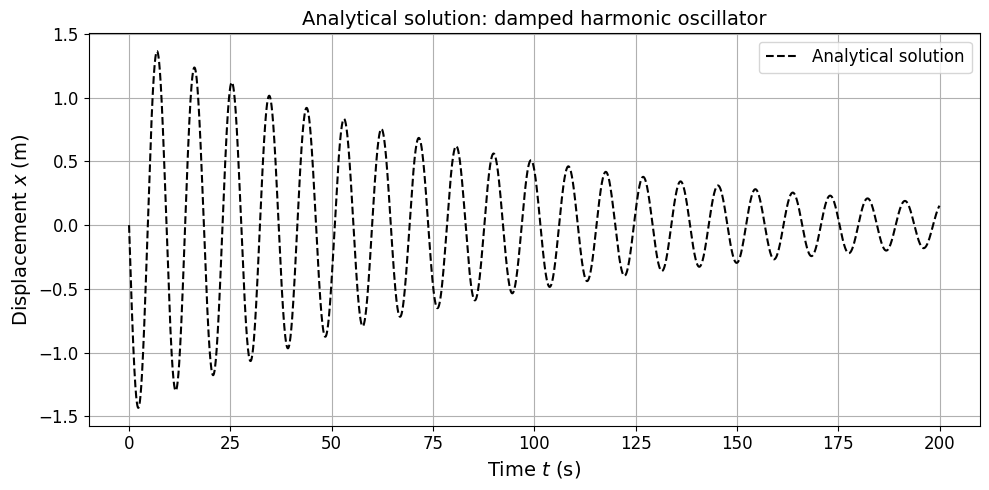

In [106]:
t_an = np.arange(0, T, h)
x_an = analytical(x_0, v_0, t_an, b)

plt.figure(figsize=(10, 5))
plt.plot(t_an, x_an, label="Analytical solution", color='black', linestyle='--')
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Analytical solution: damped harmonic oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The analytical solution shows smooth exponential decay of the oscillation amplitude, consistent with the underdamped regime ($b \ll b_{cr}$). The solution serves as the exact benchmark against which the accuracy of the four numerical methods is assessed in the following section.

## 4 Accuracy Comparison

Numerical methods introduce discretisation error - a consequence of evaluating the solution at discrete timesteps rather than continuously.

Three categories of error arise in numerical simulations of this kind: modelisation error (assumptions of linear restoring and damping forces), discretisation error (controlled by the timestep size $h$), and computing error (floating-point rounding). Here we focus on discretisation error, which is the dominant source of inaccuracy in the methods implemented above.

### 4.1 Comparison with the Analytical Solution

All four numerical methods are plotted alongside the analytical solution to provide a qualitative assessment of accuracy.

Two timestep sizes are shown: $h = 0.01$ s where all methods agree closely, and $h = 0.1$ s where differences become apparent.

A comparison is plotted below.

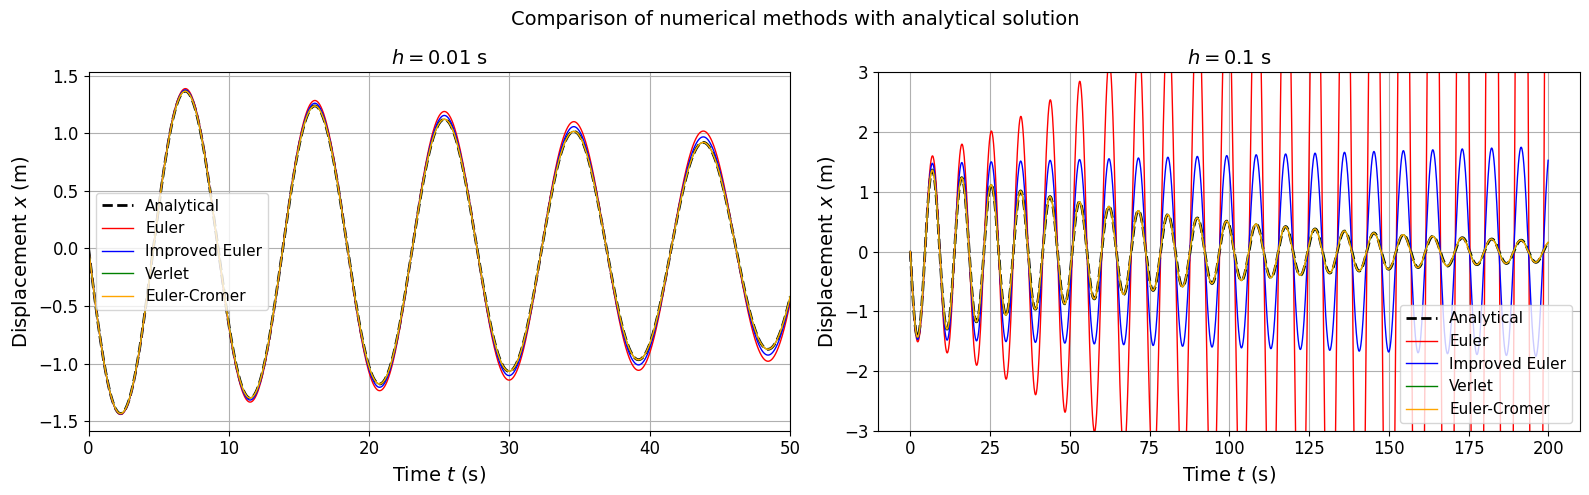

In [107]:
# Plot 1 - small h where methods agree closely
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: h = 0.01 (default)
axes[0].plot(t_an, x_an, label="Analytical", color='black', linestyle='--', linewidth=2)
axes[0].plot(t_eu, x_eu, label="Euler", color='red', linewidth=1)
axes[0].plot(t_ie, x_ie, label="Improved Euler", color='blue', linewidth=1)
axes[0].plot(t_vl, x_vl, label="Verlet", color='green', linewidth=1)
axes[0].plot(t_ec, x_ec, label="Euler-Cromer", color='orange', linewidth=1)
axes[0].set_xlim(0, 50)
axes[0].set_xlabel("Time $t$ (s)", fontsize=14)
axes[0].set_ylabel("Displacement $x$ (m)", fontsize=14)
axes[0].set_title("$h = 0.01$ s", fontsize=14)
axes[0].legend(fontsize=11)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(True)

# Right plot: h = 0.1 (large - differences visible)
h_large = 0.1
n_large = int(T / h_large)
t_an_l = np.arange(0, n_large * h_large, h_large)
x_an_l = analytical(x_0, v_0, t_an_l, b)
_, x_eu_l, _ = Euler(x_0, v_0, n_large, h_large, b)
_, x_ie_l, _ = ImprovedEuler(x_0, v_0, n_large, h_large, b)
_, x_vl_l, _ = Verlet(x_0, v_0, n_large, h_large, b)
_, x_ec_l, _ = EulerCromer(x_0, v_0, n_large, h_large, b)

axes[1].plot(t_an_l, x_an_l, label="Analytical", color='black', linestyle='--', linewidth=2)
axes[1].plot(t_an_l, x_eu_l, label="Euler", color='red', linewidth=1)
axes[1].plot(t_an_l, x_ie_l, label="Improved Euler", color='blue',   linewidth=1)
axes[1].plot(t_an_l, x_vl_l, label="Verlet", color='green', linewidth=1)
axes[1].plot(t_an_l, x_ec_l, label="Euler-Cromer", color='orange', linewidth=1)
axes[1].set_ylim(-3, 3)
axes[1].set_xlabel("Time $t$ (s)", fontsize=14)
axes[1].set_ylabel("Displacement $x$ (m)", fontsize=14)
axes[1].set_title("$h = 0.1$ s", fontsize=14)
axes[1].legend(fontsize=11)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(True)

plt.suptitle("Comparison of numerical methods with analytical solution", fontsize=14)
plt.tight_layout()
plt.show()

At $h=0.01$ s (left panel), all four numerical methods agree closely with the analytical solution over the first 50 s. Differences between methods are barely visible at this scale, although careful inspection shows that Euler (red) drifts slightly above the analytical solution at later times, consistent with its tendency to gain energy at each timestep, as discussed in Section 2.1.

At $h=0.1$ (right panel), the limitations of the methods become clear. The Euler method is numerically unstable - its amplitude grows rather than decaying, confirming the artificial energy gain $E_{i+1} = E_i(1+kh^2/m)$ derived in Section 2.1. The Improved Euler maintains a roughly constant amplitude, avoiding the dramatic instability of Euler, but fails to correctly capture the exponential decay at this large timestep. By contrast, the Verlet and Euler-Cromer methods continue to track the analytical solution closely, with both the amplitude decay and oscillation frequency reproduced accurately.

### 4.2 Effect of Timestep Size

Rather than relying on visual comparison alone, the root mean square (RMS) error provides a single quantitative measure of the average deviation from the analytical solution across all timesteps, allowing rigorous comparison between methods.

The RMS error is computed as a function of timestep size $h$:

$$\epsilon = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(x_{\text{num},i} - x_{\text{exact},i}\right)^2} ,$$

where $N$ is the number of timesteps. This measures the average deviation of the numerical solution from the analytical solution over the simulation window $t \in [0, 50]$ s.

If a method has global error $O(h^p)$, then on a log-log plot of $\epsilon$ against $h$ the gradient should equal $p$. This provides a direct numerical verification of the theoretical error orders derived in Section 2.

This log-log relationship is plotted below.

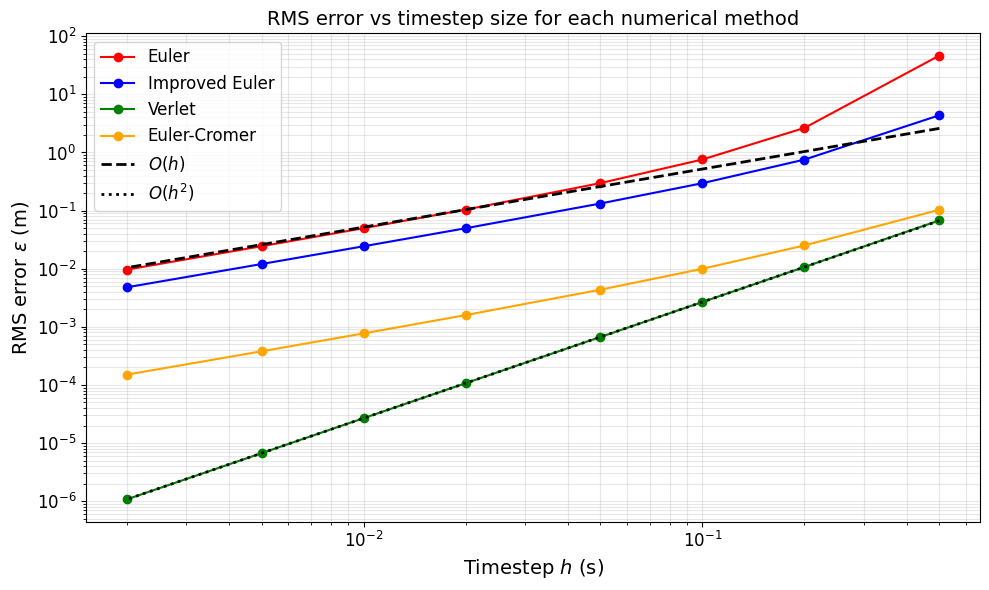

In [108]:
h_values = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
T_short = 50

errors = {
    "Euler":          [],
    "Improved Euler": [],
    "Verlet":         [],
    "Euler-Cromer":   [],
}

for h_test in h_values:
    n = int(T_short / h_test)
    t_ref = np.arange(0, n * h_test, h_test)
    n = len(t_ref) # Ensure consistent length
    x_ref = analytical(x_0, v_0, t_ref, b)

    _, x_eu_t, _ = Euler(x_0, v_0, n, h_test, b)
    errors["Euler"].append(np.sqrt(np.mean((x_eu_t - x_ref)**2)))

    _, x_ie_t, _ = ImprovedEuler(x_0, v_0, n, h_test, b)
    errors["Improved Euler"].append(np.sqrt(np.mean((x_ie_t - x_ref)**2)))

    _, x_vl_t, _ = Verlet(x_0, v_0, n, h_test, b)
    errors["Verlet"].append(np.sqrt(np.mean((x_vl_t - x_ref)**2)))

    _, x_ec_t, _ = EulerCromer(x_0, v_0, n, h_test, b)
    errors["Euler-Cromer"].append(np.sqrt(np.mean((x_ec_t - x_ref)**2)))

h_arr = np.array(h_values)
colors = {"Euler": "red", "Improved Euler": "blue", "Verlet": "green", "Euler-Cromer": "orange"}

plt.figure(figsize=(10, 6))

for method, err in errors.items():
    plt.loglog(h_arr, err, 'o-', label=method, color=colors[method])

# Anchor reference lines to middle of data range
mid = len(h_values) // 2
plt.loglog(h_arr, h_arr**1 * errors["Euler"][mid] / h_values[mid]**1, 'k--', linewidth=2, label=r"$O(h)$")
plt.loglog(h_arr, h_arr**2 * errors["Verlet"][mid] / h_values[mid]**2, 'k:', linewidth=2, label=r"$O(h^2)$")
plt.xlabel("Timestep $h$ (s)", fontsize=14)
plt.ylabel(r"RMS error $\epsilon$ (m)", fontsize=14)
plt.title("RMS error vs timestep size for each numerical method", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

The RMS errors are plotted on logarithmic axes (log-log), where a method with global error $O(h^p)$ appears as a straight line with gradient $p$. 

Two reference lines of gradient 1 and 2 are included, corresponding to $O(h)$ and $O(h^2)$ scaling respectively.

The Verlet method (green) produces the smallest errors across all timesteps tested, with RMS errors several orders of magnitude below the other methods at small $h$. Its slope closely follows the $O(h^2)$ reference line, confirming the second-order global convergence predicted by the centred-difference derivation in Section 2.3. This means that halving the timestep reduces the Verlet error by roughly a factor of four.

The remaining three methods - Euler, Improved Euler, and Euler-Cromer - all follow approximately the $O(h)$ reference line, consistent with first-order global convergence as discussed in Sections 2.1, 2.2, and 2.4.

Halving the timestep only halves the error for these methods. Among them, Euler (red) produces the largest errors and becomes unstable at large timesteps ($h \gtrsim 0.1$ s), where the uncontrolled energy growth discussed in Section 2.1 causes the amplitude to diverge.

The Euler-Cromer method (orange) achieves consistently lower errors than both Euler and Improved Euler despite sharing the same convergence order, reflecting its symplectic character (energy errors oscillate rather than accumulate), as discussed in Section 2.4.

Over the timestep range shown, the Euler and Improved Euler errors continue to decrease as $h$ decreases, with no clear plateau visible to indicate that floating-point round-off error is dominating.

Based on this analysis, the **Verlet method** is clearly the most accurate of the four methods and is selected for all subsequent physics investigations in this project.

## 5 Physics of the Damped Harmonic Oscillator

Having established the Verlet method as the most accurate numerical integrator in Section 4, it is now used exclusively to explore the physical behaviour of the damped harmonic oscillator under varying conditions.

### 5.1 Damping Regimes

The behaviour of the unforced oscillator depends critically on the damping coefficient $b$ relative to the critical value

$$
b_{cr} = 2\sqrt{km} = 2\sqrt{2.17 \times 4.68} = 6.37 \; \text{kg/s}.
$$

As introduced in Section 3, three distinct regimes exist:

- **Underdamped** ($b < b_{cr}$): The system oscillates with exponentially decaying amplitude
- **Critically damped** ($b = b_{cr}$): The fastest return to equilibrium without oscillation
- **Overdamped** ($b > b_{cr}$): A slow, non-oscillatory return to equilibrium

The Verlet method is used to simulate all three regimes, with $b$ set to $b_{cr}/2$, $b_{cr}$, and $2b_{cr}$ respectively. The analytical solution (Section 3) was verified to agree with the numerical results to within RMS errors of order $10^{-6}$–$10^{-5}$ m in all three cases. This is shown below.

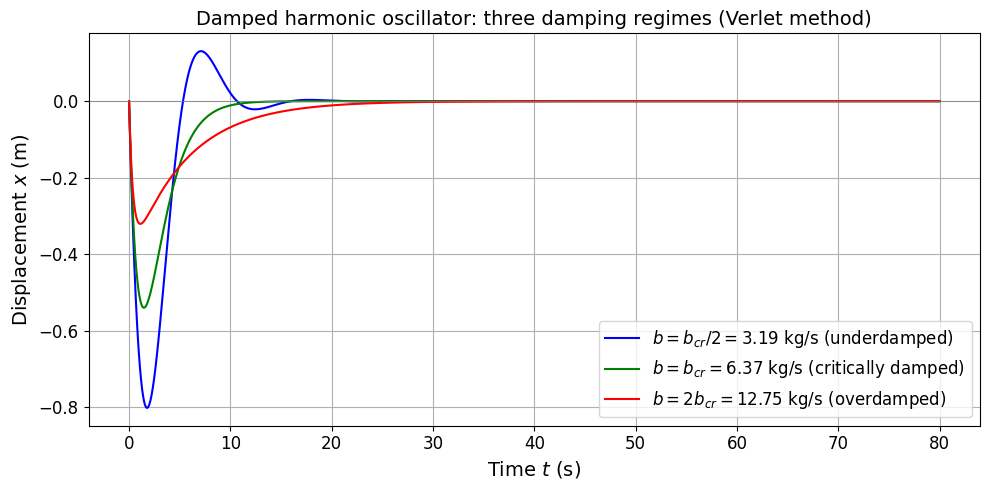

In [109]:
# Critical damping coefficient and damping values for the three regimes
b_cr = 2 * np.sqrt(k * m)
omega_0 = np.sqrt(k / m)

b_half = b_cr / 2
b_double = 2 * b_cr

# Simulation parameters
T_damp = 80
h_damp = 0.01
n_damp = int(T_damp / h_damp)

# Run Verlet for each damping regime
t_ud, x_ud, _ = Verlet(x_0, v_0, n_damp, h_damp, b_half)
t_cd, x_cd, _ = Verlet(x_0, v_0, n_damp, h_damp, b_cr)
t_od, x_od, _ = Verlet(x_0, v_0, n_damp, h_damp, b_double)

# Plot all three regimes
plt.figure(figsize=(10, 5))
plt.plot(t_ud, x_ud, color='blue', label=rf"$b = b_{{cr}}/2 = {b_half:.2f}$ kg/s (underdamped)")
plt.plot(t_cd, x_cd, color='green', label=rf"$b = b_{{cr}} = {b_cr:.2f}$ kg/s (critically damped)")
plt.plot(t_od, x_od, color='red', label=rf"$b = 2b_{{cr}} = {b_double:.2f}$ kg/s (overdamped)")
plt.axhline(y=0, color='grey', linewidth=0.5)
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Damped harmonic oscillator: three damping regimes (Verlet method)", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The three damping regimes produce qualitatively distinct behaviour, all starting from the same initial conditions ($x_0 = 0$ m, $v_0 = -1$ m/s). Since the oscillator begins at equilibrium with a negative velocity, all three solutions move initially in the negative direction. Only the underdamped case has sufficient energy to overshoot equilibrium on the return, producing a small positive displacement before decaying - the critically damped and overdamped solutions approach zero monotonically from below.

In the **underdamped** case ($b = b_{cr}/2 = 3.19$ kg/s), the system oscillates with a decaying amplitude, overshooting equilibrium several times before settling. The oscillation frequency is reduced compared to the natural frequency $\omega_0$ due to the damping - the modified frequency is $\omega = \sqrt{\omega_0^2 - \gamma^2/4}$, where $\gamma = b/m$.

In the **critically damped** case ($b = b_{cr} = 6.37$ kg/s), the system returns to equilibrium as fast as possible without oscillating. The displacement approaches zero monotonically after a single extremum, reaching equilibrium faster than either of the other two regimes. This makes critical damping optimal for applications such as shock absorbers and instrument needle returns, where rapid settling without overshoot is desired.

In the **overdamped** case ($b = 2b_{cr} = 12.75$ kg/s), the system also returns to equilibrium without oscillation, but more slowly than the critically damped case. The excessive damping impedes the motion, so the system takes longer to reach equilibrium.

The key observation is that critical damping represents the boundary between oscillatory and non-oscillatory behaviour: any reduction in $b$ below $b_{cr}$ introduces oscillation, while any increase above $b_{cr}$ slows the return to equilibrium without providing any benefit.

### 5.2 Sudden Application of an External Force

A short impulse, a constant force $F_0 = 5$ N applied over an interval $\Delta t = 0.5$ s, is used to model a sudden "push" applied to the oscillator after several oscillation periods. Outside this interval, $F(t) = 0$.

The energy transferred by such a push is $W = \int F \, v \, \mathrm{d}t$, so the effect depends critically on the relationship between the force direction and the instantaneous velocity. Three cases are explored:

1. Push in the **same direction** as the velocity (at a zero crossing, where $|v|$ is large)
2. Push in the **opposite direction** to the velocity (at the same zero crossing)
3. Push at a **turning point** (where $v \approx 0$ and $|x|$ is large)

The natural period is $T_0 = 2\pi/\omega_0 \approx 9.23$ s, so pushing at $t \approx 37$ s corresponds to roughly four complete oscillation periods. The push times are chosen by inspecting the unforced velocity to confirm that $t = 37$ s is near a zero crossing of $x$ (large $|v|$) and $t = 34.5$ s is near a turning point ($v \approx 0$).

In [110]:
# Impulse parameters
F0 = 5.0   # Force magnitude (N)
dt_push = 0.5   # Push duration (s)

def make_push(t_start, direction):
    """
    Create a short impulse force function.

    Parameters
    ----------
    t_start   : float - time at which the push begins (s)
    direction : float - sign of the force (+1 or -1)
    """
    def F(t):
        if t_start <= t < t_start + dt_push:
            return direction * F0
        return 0.0
    return F

# Simulation parameters
T_push = 100
n_push = int(T_push / h)

# Unforced reference
t_unf, x_unf, v_unf = Verlet(x_0, v_0, n_push, h, b)

The three push cases are now computed and plotted individually. In each plot, the forced solution (solid) is compared against the unforced reference (dashed), and the shaded region marks the push interval.

In [111]:
# Case 1: push WITH velocity at t = 37 s (velocity is negative → force is negative)
t_pw, x_pw, _ = Verlet(x_0, v_0, n_push, h, b, make_push(37.0, -1.0))

# Case 2: push AGAINST velocity at t = 37 s (velocity is negative → force is positive)
t_pa, x_pa, _ = Verlet(x_0, v_0, n_push, h, b, make_push(37.0, +1.0))

# Case 3: push at TURNING POINT at t = 34.5 s
t_pt, x_pt, _ = Verlet(x_0, v_0, n_push, h, b, make_push(34.5, -1.0))

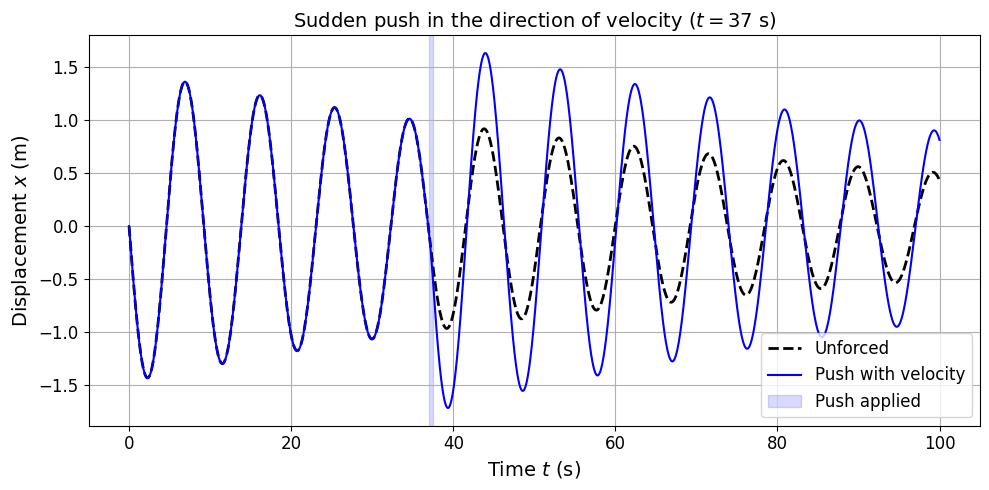

In [112]:
# Push in the direction of velocity
plt.figure(figsize=(10, 5))
plt.plot(t_unf, x_unf, 'k--', linewidth=2, label="Unforced")
plt.plot(t_pw, x_pw, color='blue', linewidth=1.5, label="Push with velocity")
plt.axvspan(37.0, 37.5, alpha=0.15, color='blue', label='Push applied')
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Sudden push in the direction of velocity ($t = 37$ s)", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

When the push acts in the same direction as the velocity, the force does positive work on the system ($W = \int F \, v \, \mathrm{d}t > 0$), transferring energy into the oscillator. The amplitude increases immediately after the push and remains larger than the unforced solution for the remainder of the simulation. The oscillation frequency is unchanged - the push modifies the energy but not the natural frequency of the system.

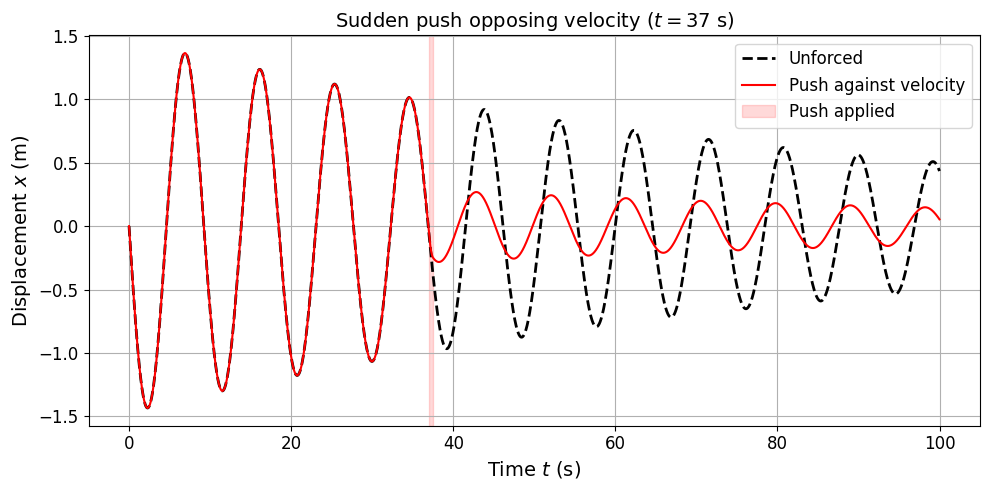

In [113]:
# Push opposing the velocity
plt.figure(figsize=(10, 5))
plt.plot(t_unf, x_unf, 'k--', linewidth=2, label="Unforced")
plt.plot(t_pa, x_pa, color='red', linewidth=1.5, label="Push against velocity")
plt.axvspan(37.0, 37.5, alpha=0.15, color='red', label='Push applied')
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title("Sudden push opposing velocity ($t = 37$ s)", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

When the push opposes the velocity, the force does negative work ($W < 0$), removing energy from the oscillator. The amplitude drops sharply, the system is nearly brought to rest by the push, and the subsequent oscillations are much smaller than the unforced case. This is the principle behind braking and damping mechanisms: applying a force opposing the motion removes kinetic energy most efficiently.

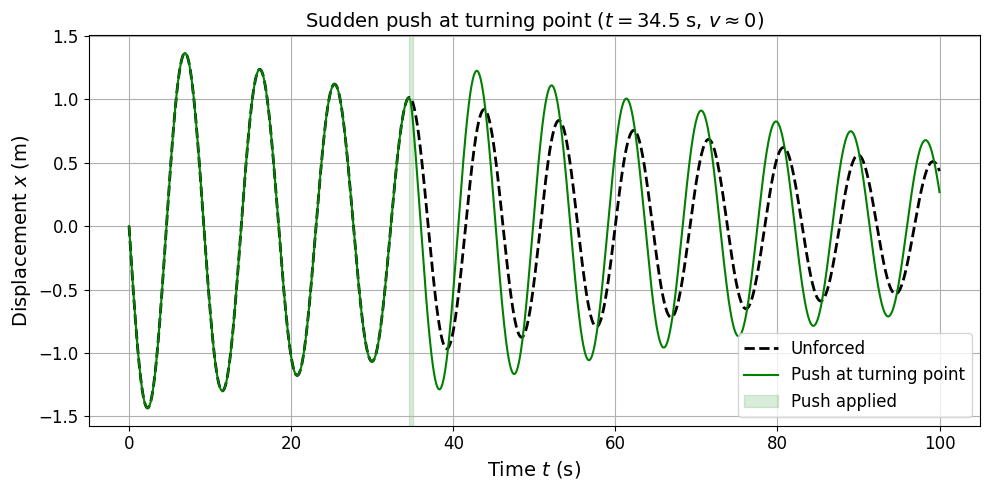

In [114]:
# Push at turning point
plt.figure(figsize=(10, 5))
plt.plot(t_unf, x_unf, 'k--', linewidth=2, label="Unforced")
plt.plot(t_pt, x_pt, color='green', linewidth=1.5, label="Push at turning point")
plt.axvspan(34.5, 35.0, alpha=0.15, color='green', label='Push applied')
plt.xlabel("Time $t$ (s)", fontsize=14)
plt.ylabel("Displacement $x$ (m)", fontsize=14)
plt.title(r"Sudden push at turning point ($t = 34.5$ s, $v \approx 0$)", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

When the push is applied at a turning point, the velocity is close to zero, so the instantaneous rate of work $F \cdot v$ is initially small. However, the force accelerates the mass during the push interval, so the total work done is nonzero. The resulting amplitude increase is smaller than in the "push with velocity" case, where the velocity was already large and aligned with the force.

This is consistent with the work–energy interpretation: the energy transferred by a sudden push depends on $\int F \, v \, \mathrm{d}t$ over the push duration. Pushing when the velocity is large and aligned with the force transfers the most energy; pushing when the velocity is near zero transfers less, regardless of the force magnitude.

### 5.3 Sinusoidal External Forcing

A continuous sinusoidal driving force is now applied to the oscillator, so that the equation of motion becomes

$$
m\ddot{x} + b\dot{x} + kx = F_0 \sin(\omega_d t),
$$

where $F_0$ is the driving amplitude and $\omega_d$ is the driving frequency. For the present system, the undamped natural frequency is $\omega_0 = \sqrt{k/m} \approx 0.68$ rad/s, and the driving frequency is chosen as $\omega_d = 0.50$ rad/s so that $\omega_d \neq \omega_0$.

Unlike the sudden push in Section 5.2, a sinusoidal driving force continuously transfers energy into the system. The resulting motion consists of a transient contribution (the natural damped response, which decays) and a steady-state contribution (driven by $F(t)$, which persists). At late times, only the steady-state oscillation remains.

The theoretical steady-state amplitude is

$$
A(\omega_d) = \frac{F_0}{\sqrt{(k - m\omega_d^2)^2 + (b\omega_d)^2}},
$$

against which the numerical result can be checked.

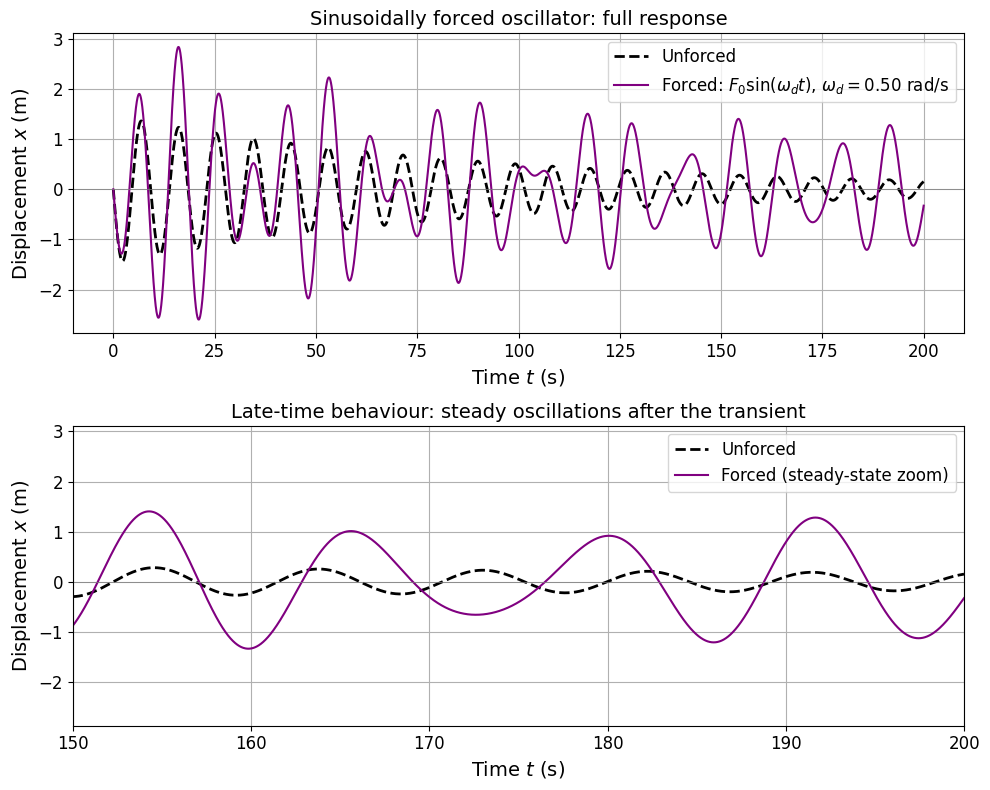

In [115]:
# Driving-force parameters
F0_drive = 1.0 # Driving force amplitude (N)
omega_d = 0.50 # Driving frequency (rad/s)

def F_drive(t):
    """
    Continuous sinusoidal driving force.

    Parameters
    ----------
    t : float - time (s)
    """
    return F0_drive * np.sin(omega_d * t)

# Simulation parameters
T_drive = 200
n_drive = int(T_drive / h)

# Run unforced and forced solutions using Verlet
t_unf_drive, x_unf_drive, _ = Verlet(x_0, v_0, n_drive, h, b)
t_forced, x_forced, _ = Verlet(x_0, v_0, n_drive, h, b, F_drive)

# Steady-state analysis: final four driving periods
T_d = 2 * np.pi / omega_d
t_steady_start = T_drive - 4 * T_d
steady_mask = t_forced >= t_steady_start

# Numerical steady-state amplitude
A_num = 0.5 * (np.max(x_forced[steady_mask]) - np.min(x_forced[steady_mask]))

# Theoretical steady-state amplitude
A_theory = F0_drive / np.sqrt((k - m * omega_d**2)**2 + (b * omega_d)**2)

# Plot full response and late-time steady state
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top panel: full time range
axes[0].plot(t_unf_drive, x_unf_drive, 'k--', linewidth=2, label="Unforced")
axes[0].plot(t_forced, x_forced, color='purple', linewidth=1.5, label=rf"Forced: $F_0\sin(\omega_d t)$, $\omega_d={omega_d:.2f}$ rad/s")
axes[0].axhline(y=0, color='grey', linewidth=0.5)
axes[0].set_xlabel("Time $t$ (s)", fontsize=14)
axes[0].set_ylabel("Displacement $x$ (m)", fontsize=14)
axes[0].set_title("Sinusoidally forced oscillator: full response", fontsize=14)
axes[0].legend(fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(True)

# Bottom panel: late-time zoom
axes[1].plot(t_unf_drive, x_unf_drive, 'k--', linewidth=2, label="Unforced")
axes[1].plot(t_forced, x_forced, color='purple', linewidth=1.5, label="Forced (steady-state zoom)")
axes[1].axhline(y=0, color='grey', linewidth=0.5)
axes[1].set_xlim(150, 200)
axes[1].set_xlabel("Time $t$ (s)", fontsize=14)
axes[1].set_ylabel("Displacement $x$ (m)", fontsize=14)
axes[1].set_title("Late-time behaviour: steady oscillations after the transient", fontsize=14)
axes[1].legend(fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

The upper panel shows the full time evolution. The unforced solution (dashed) decays steadily to zero as damping removes energy, while the forced solution (purple) does not decay to rest, instead transitioning from an initial transient into a persistent steady-state oscillation.

The lower panel confirms that the late-time motion is a clean periodic oscillation at the driving frequency $\omega_d$, not the natural frequency $\omega_0$. This is the defining feature of a driven damped oscillator: damping suppresses the homogeneous (transient) part of the solution, leaving only the particular solution forced by the external input.

The numerical steady-state amplitude agrees closely with the theoretical prediction, confirming that the Verlet method remains accurate in the presence of continuous external forcing.

This behaviour is qualitatively different from the sudden-push case in Section 5.2: a sudden push changes the energy only once, after which the motion decays freely, whereas a sinusoidal driving force continuously supplies energy and can sustain oscillations indefinitely despite damping.

## 6 Resonance of the Forced Damped Oscillator

When the driving frequency $\omega_d$ is swept across a range of values, the steady-state amplitude $A(\omega_d)$ exhibits a peak near the natural frequency - this is **resonance**.

As already mentioned in the section above, the theoretical steady-state amplitude is $ A(\omega_d) = F_0/\sqrt{(k - m\omega_d^2)^2 + (b\omega_d)^2},$ which reaches a maximum not at $\omega_0$, but at the resonance frequency

$$
\omega_{\mathrm{res}} = \sqrt{\omega_0^2 - \frac{\gamma^2}{2}},
$$

where $\gamma = \frac{b}{m}$.

The shift of the peak below $\omega_0$ is a direct consequence of damping. In the limit of very weak damping, $\omega_{\mathrm{res}} \to \omega_0$ and the peak becomes arbitrarily sharp.

### 6.1 Numerical Resonance Curve

The resonance curve is first constructed numerically: for each value of $\omega_d$, the Verlet method is run for a sufficiently long time that the transient decays, and the steady-state amplitude is measured from the final four driving periods. The result is compared against the theoretical curve.

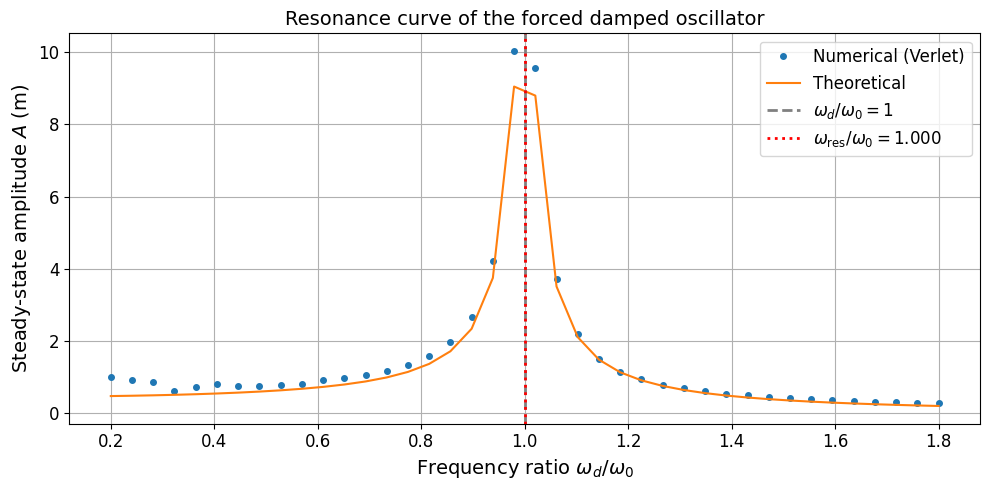

In [116]:
# Driving-force amplitude for the resonance study
F0_res = 1.0

def make_sinusoidal_force(F0, omega_d):
    """
    Return a sinusoidal driving force F(t) = F0 sin(omega_d t).

    Parameters
    ----------
    F0      : float - force amplitude (N)
    omega_d : float - driving angular frequency (rad/s)
    """
    def F(t):
        return F0 * np.sin(omega_d * t)
    return F

def steady_state_amplitude(omega_d, F0, b_val, T_total=250):
    """
    Measure the steady-state amplitude numerically from the final four driving periods.

    Parameters
    ----------
    omega_d : float - driving angular frequency (rad/s)
    F0      : float - force amplitude (N)
    b_val   : float - damping coefficient (kg/s)
    T_total : float - total simulation time (s)
    """
    n_total = int(T_total / h)
    F_func = make_sinusoidal_force(F0, omega_d)

    t_num, x_num, _ = Verlet(x_0, v_0, n_total, h, b_val, F_func)

    T_d = 2 * np.pi / omega_d
    t_start = T_total - 4 * T_d
    mask = t_num >= t_start

    return 0.5 * (np.max(x_num[mask]) - np.min(x_num[mask]))

# Natural and resonance frequencies
omega_0 = np.sqrt(k / m)
gamma = b / m
omega_res = np.sqrt(omega_0**2 - gamma**2 / 2)

# Sweep driving frequency
omega_vals = np.linspace(0.2 * omega_0, 1.8 * omega_0, 40)

A_num_res = [steady_state_amplitude(od, F0_res, b) for od in omega_vals]
A_theory_res = [F0_res / np.sqrt((k - m*od**2)**2 + (b*od)**2) for od in omega_vals]

A_num_res = np.array(A_num_res)
A_theory_res = np.array(A_theory_res)

# Plot resonance curve
plt.figure(figsize=(10, 5))
plt.plot(omega_vals / omega_0, A_num_res, 'o', markersize=4, label="Numerical (Verlet)")
plt.plot(omega_vals / omega_0, A_theory_res, linewidth=1.5, label="Theoretical")
plt.axvline(1.0, color='grey', linestyle='--', linewidth=2, label=r"$\omega_d/\omega_0 = 1$")
plt.axvline(omega_res / omega_0, color='red', linestyle=':', linewidth=2, label=rf"$\omega_{{\mathrm{{res}}}}/\omega_0 = {omega_res/omega_0:.3f}$")
plt.xlabel(r"Frequency ratio $\omega_d / \omega_0$", fontsize=14)
plt.ylabel("Steady-state amplitude $A$ (m)", fontsize=14)
plt.title("Resonance curve of the forced damped oscillator", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

The numerical amplitudes (circles) agree closely with the theoretical curve (solid line) across the full range of driving frequencies, confirming the accuracy of the Verlet method for long-time forced simulations.

The amplitude rises sharply as $\omega_d$ approaches $\omega_0$ and reaches a maximum slightly below $\omega_0$, at $\omega_{\mathrm{res}}$. For frequencies well above or below the natural frequency, the response is comparatively small. The shift of the peak below $\omega_0$ is a direct consequence of damping. In the absence of damping, the peak would occur exactly at $\omega_0$ and the amplitude would diverge.

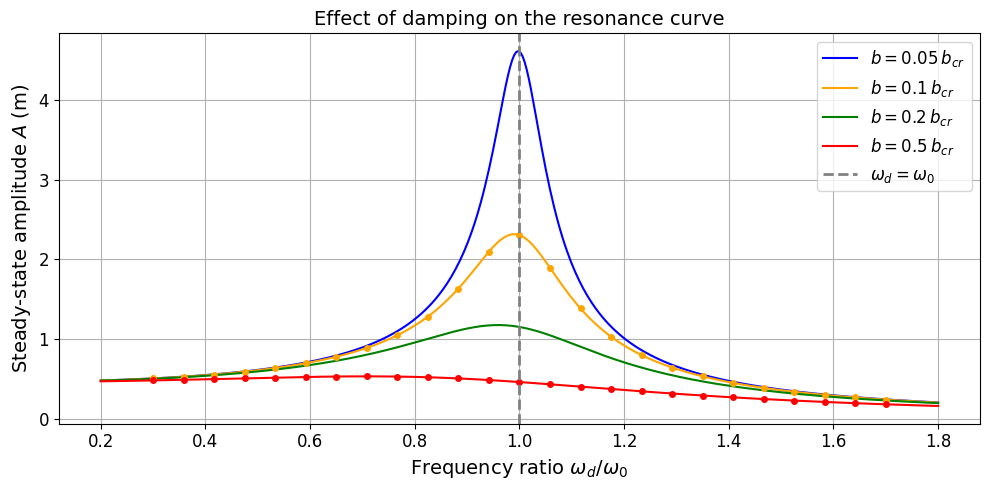

In [117]:
# Damping values to explore
b_vals = [0.05 * b_cr, 0.1 * b_cr, 0.2 * b_cr, 0.5 * b_cr]
b_labels = [r"$b = 0.05\,b_{cr}$", r"$b = 0.1\,b_{cr}$", r"$b = 0.2\,b_{cr}$", r"$b = 0.5\,b_{cr}$"]
b_colors = ['blue', 'orange', 'green', 'red']

# Fine frequency sweep for theoretical curves
omega_sweep = np.linspace(0.2 * omega_0, 1.8 * omega_0, 400)

# Coarser sweep for numerical verification (two selected damping values)
omega_num_sweep = np.linspace(0.3 * omega_0, 1.7 * omega_0, 25)
b_verify = [0.1 * b_cr, 0.5 * b_cr]  # verify lowest and highest damping

plt.figure(figsize=(10, 5))

# Plot theoretical curves
for b_val, label, col in zip(b_vals, b_labels, b_colors):
    A_curve = F0_res / np.sqrt((k - m * omega_sweep**2)**2 + (b_val * omega_sweep)**2)
    plt.plot(omega_sweep / omega_0, A_curve, linewidth=1.5, color=col, label=label)

# Overlay numerical points for two cases
for b_val, col in zip(b_verify, ['orange', 'red']):
    A_pts = [steady_state_amplitude(od, F0_res, b_val, T_total=300) for od in omega_num_sweep]
    plt.plot(omega_num_sweep / omega_0, A_pts, 'o', color=col, markersize=4)

plt.axvline(1.0, color='grey', linestyle='--', linewidth=2, label=r"$\omega_d = \omega_0$")
plt.xlabel(r"Frequency ratio $\omega_d / \omega_0$", fontsize=14)
plt.ylabel("Steady-state amplitude $A$ (m)", fontsize=14)
plt.title("Effect of damping on the resonance curve", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

For small damping, the resonance peak is tall and narrow - a driving frequency close to resonance produces a very large response, while frequencies even slightly off-resonance produce a much smaller one. As the damping increases, the peak becomes lower and broader: the oscillator responds less strongly overall, but over a wider range of driving frequencies.

The peak also shifts slightly to lower frequency with increasing damping, consistent with the expression $\omega_{\mathrm{res}} = \sqrt{\omega_0^2 - \gamma^2/2}$. For the most heavily damped case ($b = 0.5\,b_{cr}$), the peak is barely distinguishable from the off-resonance response.

The numerical points (circles) confirm that the Verlet method reproduces the theoretical prediction at both low and high damping. This is important because the low-damping case, where the transient decays slowly and the resonance peak is sharp, is the most demanding test - the simulation must run long enough for the transient to fully decay before the steady-state amplitude can be measured reliably.

Physically, lightly damped systems are especially vulnerable to resonance: even a moderate periodic driving force can produce dangerously large oscillations if its frequency is close to $\omega_{\mathrm{res}}$. Increasing the damping suppresses this effect by dissipating energy more efficiently, at the cost of a broader, flatter frequency response.

## 7 Extension: Fourth-Order Runge-Kutta Method and Phase Space Analysis

The four methods studied in this project - Euler, Improved Euler, Verlet, and Euler-Cromer - are all relatively low-order integrators. In practice, the most widely used general-purpose ODE solver is the **fourth-order Runge-Kutta method (RK4)**, which achieves a global error of $O(h^4)$ by evaluating the derivative at four carefully chosen points within each timestep.

This section implements RK4 for the damped harmonic oscillator, compares its accuracy against Verlet (the best method from Section 4), and uses both methods to construct **phase space portraits** (plots of velocity against displacement), which provide physical insight not visible in the time-domain plots used so far.

### 7.1 The Fourth-Order Runge-Kutta Method

The idea behind Runge-Kutta methods is to approximate the solution over each timestep by sampling the derivative at multiple intermediate points, then combining these samples with appropriate weights to cancel higher-order error terms.

For a system of first-order ODEs $\mathbf{y}' = \mathbf{f}(t, \mathbf{y})$, where $\mathbf{y} = (x, v)^T$ and

$$
\mathbf{f}(t, \mathbf{y}) = \begin{pmatrix} v \\ \frac{F(t) - kx - bv}{m} \end{pmatrix},
$$

the classical RK4 update is:

$$
\mathbf{k}_1 = h\,\mathbf{f}(t_i,\; \mathbf{y}_i),
$$
$$
\mathbf{k}_2 = h\,\mathbf{f}\!\left(t_i + \tfrac{h}{2},\; \mathbf{y}_i + \tfrac{\mathbf{k}_1}{2}\right),
$$
$$
\mathbf{k}_3 = h\,\mathbf{f}\!\left(t_i + \tfrac{h}{2},\; \mathbf{y}_i + \tfrac{\mathbf{k}_2}{2}\right),
$$
$$
\mathbf{k}_4 = h\,\mathbf{f}(t_i + h,\; \mathbf{y}_i + \mathbf{k}_3),
$$
$$
\mathbf{y}_{i+1} = \mathbf{y}_i + \tfrac{1}{6}(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4).
$$

Each $\mathbf{k}_j$ is a two-component vector containing increments for both $x$ and $v$. The weighted average cancels error terms up to $O(h^4)$, giving a **local truncation error of $O(h^5)$** and a **global error of $O(h^4)$** - two orders better than Verlet and three better than Euler.

The cost is four derivative evaluations per step (compared to one for Euler or Euler-Cromer), but the dramatically improved accuracy means a much larger timestep can be used for the same precision, often making RK4 faster overall.

In [118]:
def RK4(x_0, v_0, nsteps, h, b, F=None):
    """
    Solve the damped harmonic oscillator using the classical 4th-order Runge-Kutta method.

    Parameters
    ----------
    x_0, v_0 : float - initial position (m) and velocity (m/s)
    nsteps   : int   - number of timesteps
    h        : float - timestep size (s)
    b        : float - damping coefficient (kg/s)
    F        : callable or None - external force F(t); defaults to zero
    """
    # Preallocate arrays for position and velocity at each timestep
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)

    # Apply initial conditions
    x[0], v[0] = x_0, v_0

    for i in range(nsteps - 1):

        # Current time
        t_i = i * h

        # Stage 1: derivative at the start of the interval
        a1 = acceleration(x[i], v[i], t_i, b, F)
        k1x = h * v[i]
        k1v = h * a1

        # Stage 2: derivative at the midpoint, using Stage 1
        a2 = acceleration(x[i] + 0.5*k1x, v[i] + 0.5*k1v, t_i + 0.5*h, b, F)
        k2x = h * (v[i] + 0.5*k1v)
        k2v = h * a2

        # Stage 3: derivative at the midpoint, using Stage 2
        a3 = acceleration(x[i] + 0.5*k2x, v[i] + 0.5*k2v, t_i + 0.5*h, b, F)
        k3x = h * (v[i] + 0.5*k2v)
        k3v = h * a3

        # Stage 4: derivative at the end of the interval, using Stage 3
        a4 = acceleration(x[i] + k3x, v[i] + k3v, t_i + h, b, F)
        k4x = h * (v[i] + k3v)
        k4v = h * a4

        # Weighted average update
        x[i+1] = x[i] + (k1x + 2*k2x + 2*k3x + k4x) / 6
        v[i+1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) / 6

    # Build time array corresponding to each step
    t = np.arange(0, nsteps * h, h)

    return t, x, v

### 7.2 Accuracy Comparison: RK4 vs Verlet

The RMS error analysis from Section 4 is now repeated with RK4 included. If RK4 achieves $O(h^4)$ global convergence, its errors should follow a line of gradient 4 on the log-log plot - two orders steeper than Verlet's gradient of 2.

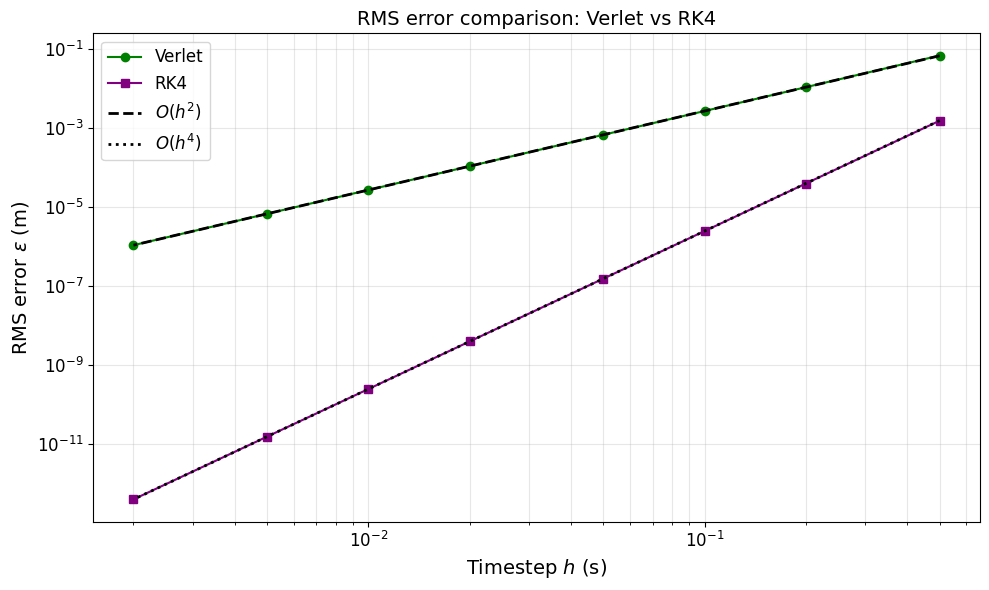

In [119]:
# Recompute RMS errors including RK4
h_values_rk = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
T_short_rk = 50

errors_vl = []
errors_rk4 = []

for h_test in h_values_rk:
    n = int(T_short_rk / h_test)
    t_ref = np.arange(0, n * h_test, h_test)
    n = len(t_ref)
    x_ref = analytical(x_0, v_0, t_ref, b)

    # Verlet
    _, x_vl_t, _ = Verlet(x_0, v_0, n, h_test, b)
    errors_vl.append(np.sqrt(np.mean((x_vl_t - x_ref)**2)))

    # RK4
    _, x_rk_t, _ = RK4(x_0, v_0, n, h_test, b)
    errors_rk4.append(np.sqrt(np.mean((x_rk_t - x_ref)**2)))

h_arr_rk = np.array(h_values_rk)

plt.figure(figsize=(10, 6))
plt.loglog(h_arr_rk, errors_vl,  'o-', color='green',  label="Verlet")
plt.loglog(h_arr_rk, errors_rk4, 's-', color='purple', label="RK4")

# Reference lines anchored to midpoint
mid = len(h_values_rk) // 2
plt.loglog(h_arr_rk, h_arr_rk**2 * errors_vl[mid] / h_values_rk[mid]**2, 'k--', linewidth=2, label=r"$O(h^2)$")
plt.loglog(h_arr_rk, h_arr_rk**4 * errors_rk4[mid] / h_values_rk[mid]**4, 'k:', linewidth=2, label=r"$O(h^4)$")

plt.xlabel("Timestep $h$ (s)", fontsize=14)
plt.ylabel(r"RMS error $\epsilon$ (m)", fontsize=14)
plt.title("RMS error comparison: Verlet vs RK4", fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

The RK4 errors (purple squares) follow the $O(h^4)$ reference line closely, confirming fourth-order global convergence. At $h = 0.01$ s, RK4 achieves an RMS error several orders of magnitude smaller than Verlet, a dramatic improvement.

The practical implication is that RK4 can use a much larger timestep than Verlet for the same accuracy. Despite requiring four derivative evaluations per step (compared to one for Verlet), the ability to use larger $h$ typically makes RK4 more efficient overall. This explains why RK4 (and its adaptive variants) are a common choice in scientific computing.

Over the timestep range shown, the RK4 errors remain close to the expected $O(h^4)$ trend, with no strong evidence that round-off error is yet dominating.

### 7.3 Phase Space Portraits

A phase space portrait plots velocity $v$ against displacement $x$, showing the full state of the system at each instant as a single point. As time progresses, this point traces out a trajectory (or **orbit**) in phase space.

Phase space portraits reveal features that are not easily visible in time-domain plots:

- An **undamped** oscillator traces a closed ellipse - energy is conserved, so the orbit repeats indefinitely.
- A **damped** oscillator spirals inward towards the origin (the equilibrium point), with the rate of spiralling determined by the damping strength.
- A **driven** oscillator, after the transient decays, traces a closed ellipse again - this time at the driving frequency rather than the natural frequency.

These plots also expose numerical artefacts: Euler's method, which gains energy at each step, produces an orbit that spirals *outward* - a clear unphysical signature that is immediately obvious in phase space but can be difficult to spot in a time-domain plot.

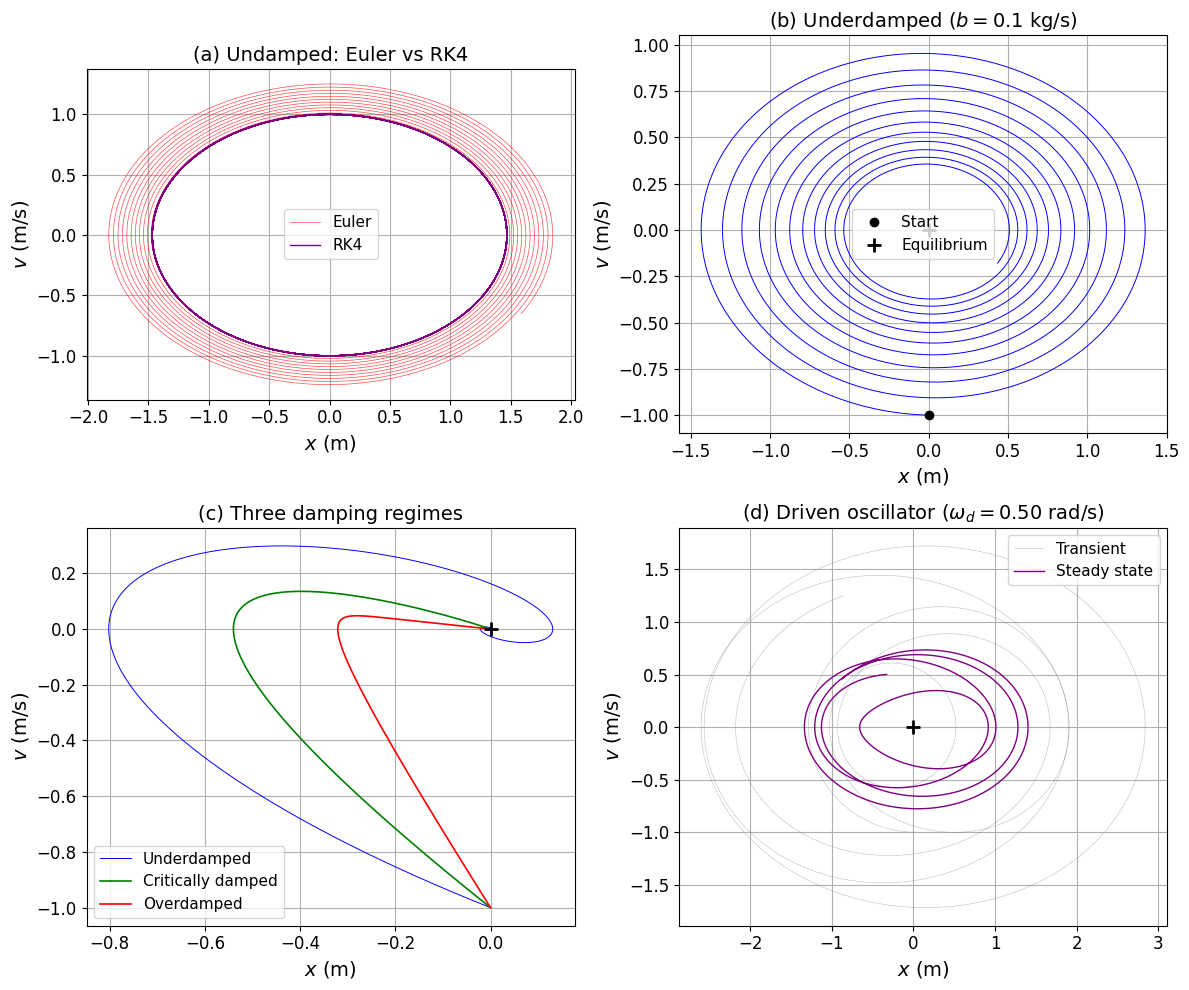

In [120]:
# Phase space portraits for four physically distinct cases
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Undamped: Euler vs RK4
T_ps = 100
n_ps = int(T_ps / h)

_, x_eu_ps, v_eu_ps = Euler(x_0, v_0, n_ps, h, 0.0)
_, x_rk_ps, v_rk_ps = RK4(x_0, v_0, n_ps, h, 0.0)

axes[0, 0].plot(x_eu_ps, v_eu_ps, color='red', linewidth=0.5, alpha=0.7, label="Euler")
axes[0, 0].plot(x_rk_ps, v_rk_ps, color='purple', linewidth=1.0, label="RK4")
axes[0, 0].set_xlabel("$x$ (m)", fontsize=14)
axes[0, 0].set_ylabel("$v$ (m/s)", fontsize=14)
axes[0, 0].set_title("(a) Undamped: Euler vs RK4", fontsize=14)
axes[0, 0].legend(fontsize=11)
axes[0, 0].tick_params(axis='both', labelsize=12)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True)

# (b) Underdamped 
_, x_ud_ps, v_ud_ps = RK4(x_0, v_0, n_ps, h, b)

axes[0, 1].plot(x_ud_ps, v_ud_ps, color='blue', linewidth=0.7)
axes[0, 1].plot(x_ud_ps[0], v_ud_ps[0], 'ko', markersize=6, label="Start")
axes[0, 1].plot(0, 0, 'k+', markersize=10, markeredgewidth=2, label="Equilibrium")
axes[0, 1].set_xlabel("$x$ (m)", fontsize=14)
axes[0, 1].set_ylabel("$v$ (m/s)", fontsize=14)
axes[0, 1].set_title(rf"(b) Underdamped ($b = {b}$ kg/s)", fontsize=14)
axes[0, 1].legend(fontsize=11)
axes[0, 1].tick_params(axis='both', labelsize=12)
axes[0, 1].grid(True)

# (c) Three damping regimes
T_ps2 = 80
n_ps2 = int(T_ps2 / h)

_, x_ud2, v_ud2 = RK4(x_0, v_0, n_ps2, h, b_half)
_, x_cd2, v_cd2 = RK4(x_0, v_0, n_ps2, h, b_cr)
_, x_od2, v_od2 = RK4(x_0, v_0, n_ps2, h, b_double)

axes[1, 0].plot(x_ud2, v_ud2, color='blue',  linewidth=0.7, label="Underdamped")
axes[1, 0].plot(x_cd2, v_cd2, color='green', linewidth=1.2, label="Critically damped")
axes[1, 0].plot(x_od2, v_od2, color='red',   linewidth=1.2, label="Overdamped")
axes[1, 0].plot(0, 0, 'k+', markersize=10, markeredgewidth=2)
axes[1, 0].set_xlabel("$x$ (m)", fontsize=14)
axes[1, 0].set_ylabel("$v$ (m/s)", fontsize=14)
axes[1, 0].set_title("(c) Three damping regimes", fontsize=14)
axes[1, 0].legend(fontsize=11)
axes[1, 0].tick_params(axis='both', labelsize=12)
axes[1, 0].grid(True)

# (d) Driven oscillator: transient → steady state
T_ps3 = 200
n_ps3 = int(T_ps3 / h)
_, x_dr, v_dr = RK4(x_0, v_0, n_ps3, h, b, F_drive)

# Split into transient (first 50 s) and steady state (last 50 s)
n_trans = int(50 / h)
n_late  = int(150 / h)

axes[1, 1].plot(x_dr[:n_trans], v_dr[:n_trans], color='grey', linewidth=0.4, alpha=0.5, label="Transient")
axes[1, 1].plot(x_dr[n_late:], v_dr[n_late:], color='purple', linewidth=1.0, label="Steady state")
axes[1, 1].plot(0, 0, 'k+', markersize=10, markeredgewidth=2)
axes[1, 1].set_xlabel("$x$ (m)", fontsize=14)
axes[1, 1].set_ylabel("$v$ (m/s)", fontsize=14)
axes[1, 1].set_title(r"(d) Driven oscillator ($\omega_d = 0.50$ rad/s)", fontsize=14)
axes[1, 1].legend(fontsize=11)
axes[1, 1].tick_params(axis='both', labelsize=12)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

The four phase space portraits each highlight a different aspect of the oscillator's behaviour.

**Panel (a)** compares Euler and RK4 for the undamped case ($b = 0$). The RK4 orbit (purple) is a closed ellipse, as expected for a conservative system with constant total energy. The Euler orbit (red) spirals outward - a direct visualisation of the artificial energy gain $E_{i+1} = E_i(1 + kh^2/m)$ derived in Section 2.1. After 100 s the Euler amplitude has grown substantially, while the RK4 orbit remains indistinguishable from the initial ellipse. This demonstrates why Euler's method is unsuitable for long-time simulations of oscillatory systems, in a way that is far more immediate than a time-domain plot.

**Panel (b)** shows the underdamped case. The orbit spirals inward towards the equilibrium point at the origin, with each loop slightly smaller than the last as damping removes energy. The spiral is smooth and the approach to equilibrium is gradual - characteristic of oscillatory decay.

**Panel (c)** overlays the three damping regimes. The underdamped trajectory (blue) spirals inward through multiple loops. The critically damped trajectory (green) approaches the origin directly, curving smoothly without completing a full orbit - this is the boundary between oscillatory and non-oscillatory behaviour. The overdamped trajectory (red) takes a similar direct path but more slowly, consistent with the sluggish return to equilibrium observed in the time-domain plot of Section 5.1.

**Panel (d)** shows the driven oscillator. The transient phase (grey) produces an irregular spiral as the natural and driven responses interfere. Once the transient decays, the steady-state orbit (purple) settles into a clean closed ellipse. The system now oscillates periodically at the driving frequency $\omega_d$, tracing the same path indefinitely. The shape and size of this ellipse encode the steady-state amplitude and the phase lag between the driving force and the displacement.

### 7.4 Summary

The fourth-order Runge-Kutta method achieves $O(h^4)$ global convergence (two orders better than Verlet and three orders better than Euler), making it vastly more accurate for a given timestep. At $h = 0.01$ s, RK4 produces errors orders of magnitude smaller than any of the four methods studied in the main project.

Phase space portraits provide a complementary view of the oscillator's dynamics that reveals features not easily seen in time-domain plots: closed orbits for conservative systems, inward spirals for damped systems, outward spirals for numerically unstable methods, and the transition from transient to steady state in driven systems. Together, RK4 and phase space analysis extend the project beyond the prescribed methods and plots into territory that reflects how oscillatory systems are studied in professional scientific computing.

## 8 Conclusion

This project compared four numerical methods for the damped harmonic oscillator and assessed their accuracy against the analytical solution. Standard Euler was the least reliable, showing noticeable energy drift and larger errors, while Euler–Cromer and Improved Euler gave clear improvements. Verlet gave the best overall balance of accuracy, stability, and efficiency, and was therefore used for the later forcing and resonance studies.

The numerical results also reproduced the expected physical behaviour of the system, including the differences between damping regimes, the phase dependence of sudden forcing, steady-state sinusoidal response, and the resonance peak near the natural frequency. Overall, the simulations were consistent with the theoretical predictions and demonstrated how the choice of numerical method strongly affects the quality of the solution.